In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [96]:
df = pd.read_csv("Boston.csv")
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [97]:
df = df.drop("Unnamed: 0", axis=1)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [98]:
X = df.drop("medv", axis=1)
y = df["medv"]

In [99]:
X = StandardScaler().fit_transform(X)

In [100]:
reg_params = np.logspace(-4, 2, 200)
results = []

for alpha in reg_params:
    model = Ridge(alpha=alpha).fit(X, y)
    results.append(model.coef_)

np_results = np.array(results)

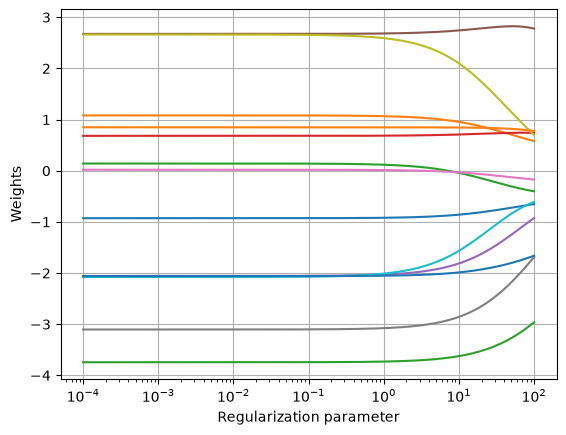

In [101]:
#for dim in range(np_results.shape[1]):
#    plt.plot(reg_params, np_results[:, dim])
plt.plot(reg_params, np_results)
plt.xscale("log")
plt.xlabel("Regularization parameter")
plt.ylabel("Weights")
plt.grid()
plt.show()

In [102]:
cv_results = []
idxs = np.arange(0, len(X))
np.random.seed(1)
np.random.shuffle(idxs)

folds = np.array_split(idxs, 5)

for alpha in reg_params:

    mses = []
    for fold in folds:
        idxs_train = np.setdiff1d(idxs, fold)
        X_train = X[idxs_train]
        y_train = y[idxs_train]

        X_test = X[fold]
        y_test = y[fold]

        lin_reg = Ridge(alpha=alpha).fit(X_train, y_train)
        y_pred = lin_reg.predict(X_test)

        mses.append(mean_squared_error(y_test, y_pred))

    cv_results.append((alpha, np.mean(mses)))

In [103]:
best_alpha, best_mse = min(cv_results, key=lambda t: t[1])
print(f"best alpha = {best_alpha}, CV MSE = {best_mse:.4f}")

best alpha = 4.397603609302721, CV MSE = 23.5248


In [104]:
cv_results_np = np.array(cv_results)

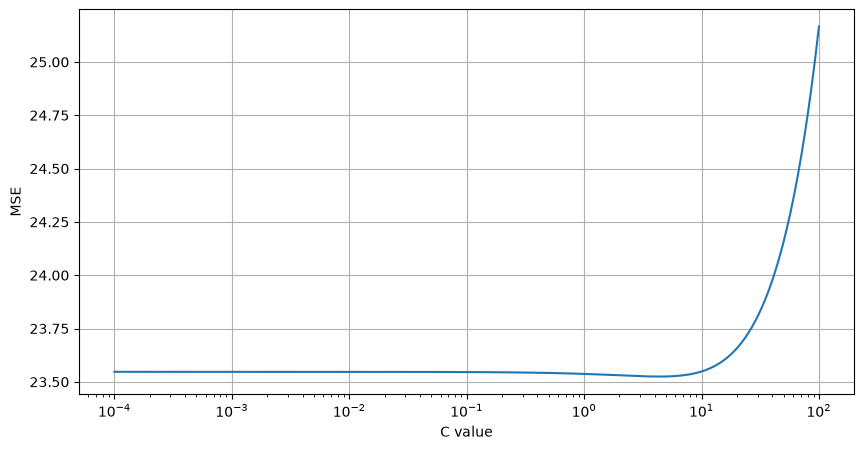

In [105]:
plt.figure(figsize=(10,5))
plt.plot(cv_results_np[:, 0], cv_results_np[:, 1])
plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("MSE")
plt.grid()
plt.show()